# Graph and Minimum Spanning Tree analysis of STM Images

### Running In Google Colab

Click the badge below to open the notebook in Colab.

Run the cell below to get setup to subsequently run the rest of notebook. **Note** you'll see a warning that the Kernel crash. This is Colab restarting

<a href="https://colab.research.google.com/github/GallagherSurfaceLab/summer_26/blob/main/STM_voronoi.ipynb" target="_blank" rel="noopener noreferrer"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
## Colab Setup
import sys
import os

IN_COLAB = 'google.colab' in sys.modules

print(f"Running in Colab: {IN_COLAB}")

if IN_COLAB:
    !wget https://raw.githubusercontent.com/GallagherSurfaceLab/summer_26/refs/heads/main/stm_voronoi_mst.py
    !wget https://raw.githubusercontent.com/GallagherSurfaceLab/summer_26/refs/heads/main//STM_Images/1912200011.png


Running in Colab: False


In [40]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import stm_voronoi_mst
importlib.reload(stm_voronoi_mst)
from stm_voronoi_mst import statistics

from skimage import util, filters, color
from skimage.segmentation import watershed
from skimage.measure import label
import networkx as nx
import matplotlib.pyplot as plt

from stm_voronoi_mst import img_file, gray_process, voronoi_tree, find_nodes, statistics

In [41]:
# ==================
# FILE NAME
# ==================
f = r"z3_scale_2.png"

# ==================
# GRAYSCALE PROCESS
# ==================
dsize = 30
cutoff = 0.5

# ==================
# WATERSHED
# ==================
smooth = False
sigma = 4
low_th = 0.7
high_th = 0.8

# ==================
# VORONOI
# ==================
k = 4
power = 0.3

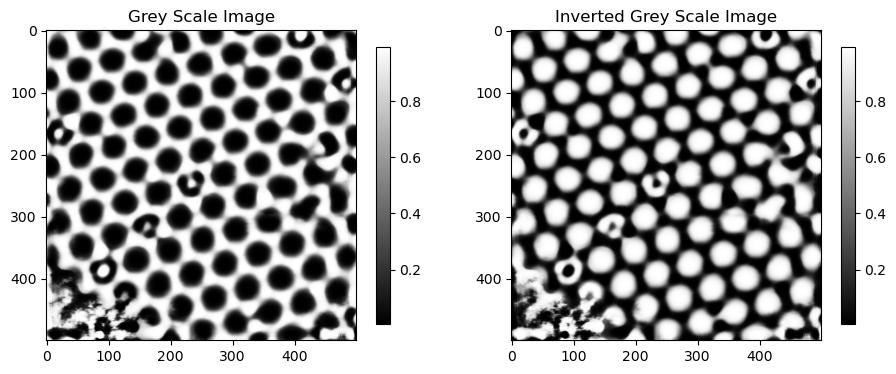

In [42]:
img = img_file(f)
img.load()

area_threshold = np.pi*0.3**2  # nm^2
px_a_th = area_threshold*img.scale**2
radius = int(img.scale/5)
if radius==0:
    radius=1

img_gr = gray_process(img.img,dsize=dsize,cutoff=cutoff) # dsize and cutoff should be adapted to image

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(11, 6))
im0 = axes[0].imshow(img_gr, cmap='gray')
axes[0].set_title('Grey Scale Image')
im1 = axes[1].imshow(util.invert(img_gr), cmap='gray')
axes[1].set_title('Inverted Grey Scale Image')

fig.colorbar(im0, ax=axes[0], shrink=0.6)
fig.colorbar(im1, ax=axes[1], shrink=0.6)

# Segmentation and Initial Labelling of the Regions

Labeling of the regions of interest are done using the the [watershed segmentation](https://scikit-image.org/docs/stable/auto_examples/applications/plot_coins_segmentation.html) technique. This requires
identifying a low threshold `low_th` which defines background pixels and a high threshold
`high_th` which defines the object we are looking at. These threshold can be determined
from the color bar of the *Inverted Grey Scale Image* about. The high threshold are the
bright regions (>0.8) and the low threshold are the dark regions (<0.2).


Text(0.5, 1.0, 'Segments overlayed on Data')

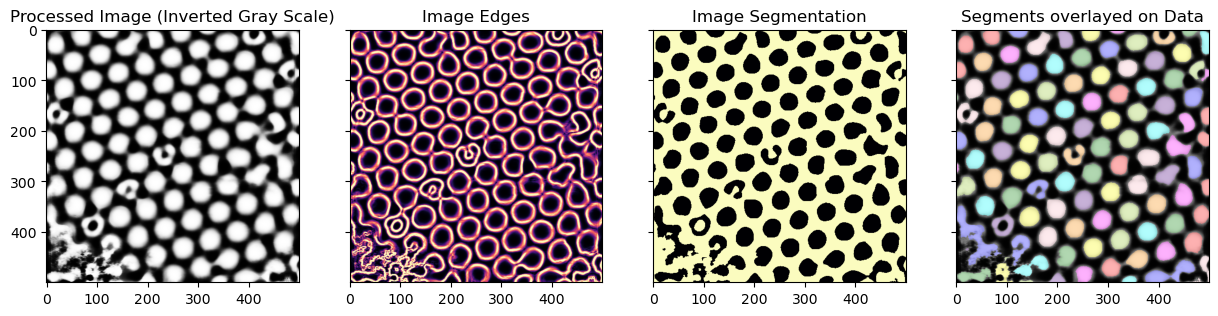

In [43]:
img_pr = util.invert(img_gr)

# defining edges of diagram
# this tells the watershed where to 
# stop when identifying regions
if smooth:
    smoothed = filters.gaussian(img_pr, sigma=sigma)
    edges = filters.sobel(smoothed)
else:
    edges = filters.sobel(img_pr)

markers = np.zeros_like(img_pr, dtype=np.int32)
# Assign label 2 to regions below the low threshold (e.g., potential background)
markers [img_pr < low_th] = 2
# Assign label 1 to regions above the high threshold (e.g., definite foreground/object)
markers [img_pr > high_th] = 1

# create segmentation (seperation of regions)
segmentation = watershed(edges, markers)
# label each region ignoring the background region
label_mask, Nlabel = label(segmentation, background=2, return_num=True)
# create a colored overlay (labeled regions overlayed on the data)
img_label_overlay = color.label2rgb(label_mask, image=img_pr)

# plot the images
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(15, 10),sharex=True, sharey=True,)
axes[0].imshow(img_pr, cmap='gray')
axes[0].set_title('Processed Image (Inverted Gray Scale)')

axes[1].imshow(edges, cmap='magma',vmax=np.percentile(edges,90))
axes[1].set_title('Image Edges')

axes[2].imshow(segmentation, cmap='magma')
axes[2].set_title('Image Segmentation')

axes[3].imshow(img_label_overlay)
axes[3].set_title('Segments overlayed on Data')

### Identifying Nodes

From the labels that were identified using the watershed tequnique we can create an 
initial graph using the `find_nodes()` function.

`find_nodes` requires a labeled segmentation mask, the number of labels, an area threshold (to drop small areas),
and a scale (to convert the pixel areas to physical areas). 

**Note** if `img.physical` is `False` then the analysis is in pixels as opposed to nm.
In this case the area threshold `px_a_th` should be in pixels and `scale` should be 1.

Below we are using a `px_a_th` of 10 pixels. ANything smaller is removed from the graph.

### Creating the Voronoi Diagram

The Voronoi diagram is created using a nearest neighbour approach to limit the number of
nodes that need to be processed. Rather than calculating the distance of every pixel to
every node, the distance from each pixel to K nearest nodes is calculated. This significantly
speeds up the code. Nearest neighbours are calculated using [SciPys cKDTree](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.cKDTree.html), you can specify the number of neighbours
to check against with `k`. 

The Voronoi fucntion also derives an *inner graph* which removes cells boardering the edge.
It also builds the graphs adjency (neigbouring cells) and edges (node to node links).

### Creating the Minimum Spanning Tree

The minimum spanning tree (MST) is created using the [NetworkX package](https://networkx.org/documentation/stable).
The MST is a subset of edges (connected nodes) where all nodes are connected 
with the minimum possible edge weight. Here the MST is using `dis` from `graph_inner` which
is the distance between each node in the graph. 


In [44]:
# Use the watershed labels to create an initial graph and set of nodes
# The properties of this graph (aka area) are determined from
# the labeled mask
graph_node = find_nodes(label_mask,Nlabel,10,img.scale)

# From the graph nodes create voronoi diagram
# graph_inner excludes edge cells
img_vor_t, img_vor_deg_t, v_border, graph_node, graph_inner, p = voronoi_tree(img, graph_node, k = k, power = power)

# Create the minimum spanning tree from the inner graph
g_msf = nx.minimum_spanning_tree(graph_inner,weight='dis') 

## Visualization

Matplotlib is used to plot all images. Multiple images can be plotted together using the
`alpha` keyword which sets the transparency of the plotted image.

Text(0.5, 1.0, 'Voronoi Overlay (Original)')

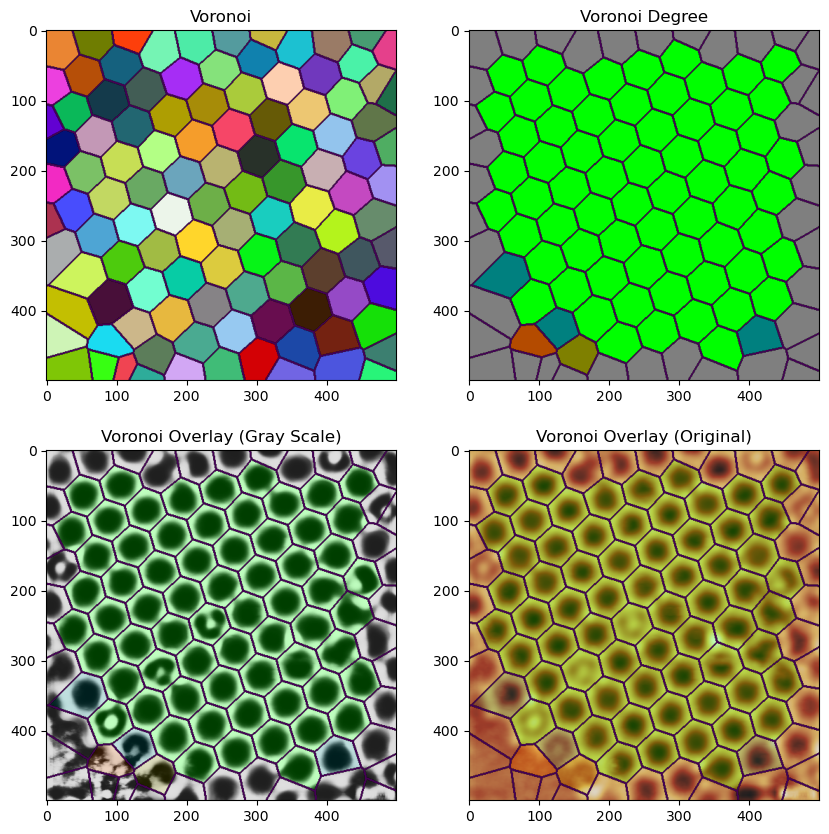

In [45]:
fig, ax = plt.subplots(2,2,figsize=(10,10))
ax[0,0].imshow(img_vor_t)
ax[0,0].imshow(v_border)
ax[0,0].set_title('Voronoi')

ax[0,1].imshow(img_vor_deg_t)
ax[0,1].imshow(v_border)
ax[0,1].set_title('Voronoi Degree')

ax[1,0].imshow(img_gr, cmap='gray')
ax[1,0].imshow(img_vor_deg_t, alpha=0.25)
ax[1,0].imshow(v_border)
ax[1,0].set_title('Voronoi Overlay (Gray Scale)')

ax[1,1].imshow(img.img)
ax[1,1].imshow(img_vor_deg_t, alpha=0.25)
ax[1,1].imshow(v_border)
ax[1,1].set_title('Voronoi Overlay (Original)')


### Plot the Graph over the Voronoi Diagram

NetworkX plotting is used to plot and overlay the Graphs on the data and Voronoi images.

--- {IMAGE INOFRMATION} ---
IMAGE SIZE:    2.0 nm
PIXELS (X):    500 px
PIXELS (Y):    500 px
IMAGE AREA:    4.0 nm^2
IMAGE SCALE:   250.0 px/nm
# OF NODES:    110
FILE NAME:     z3_scale_2.png


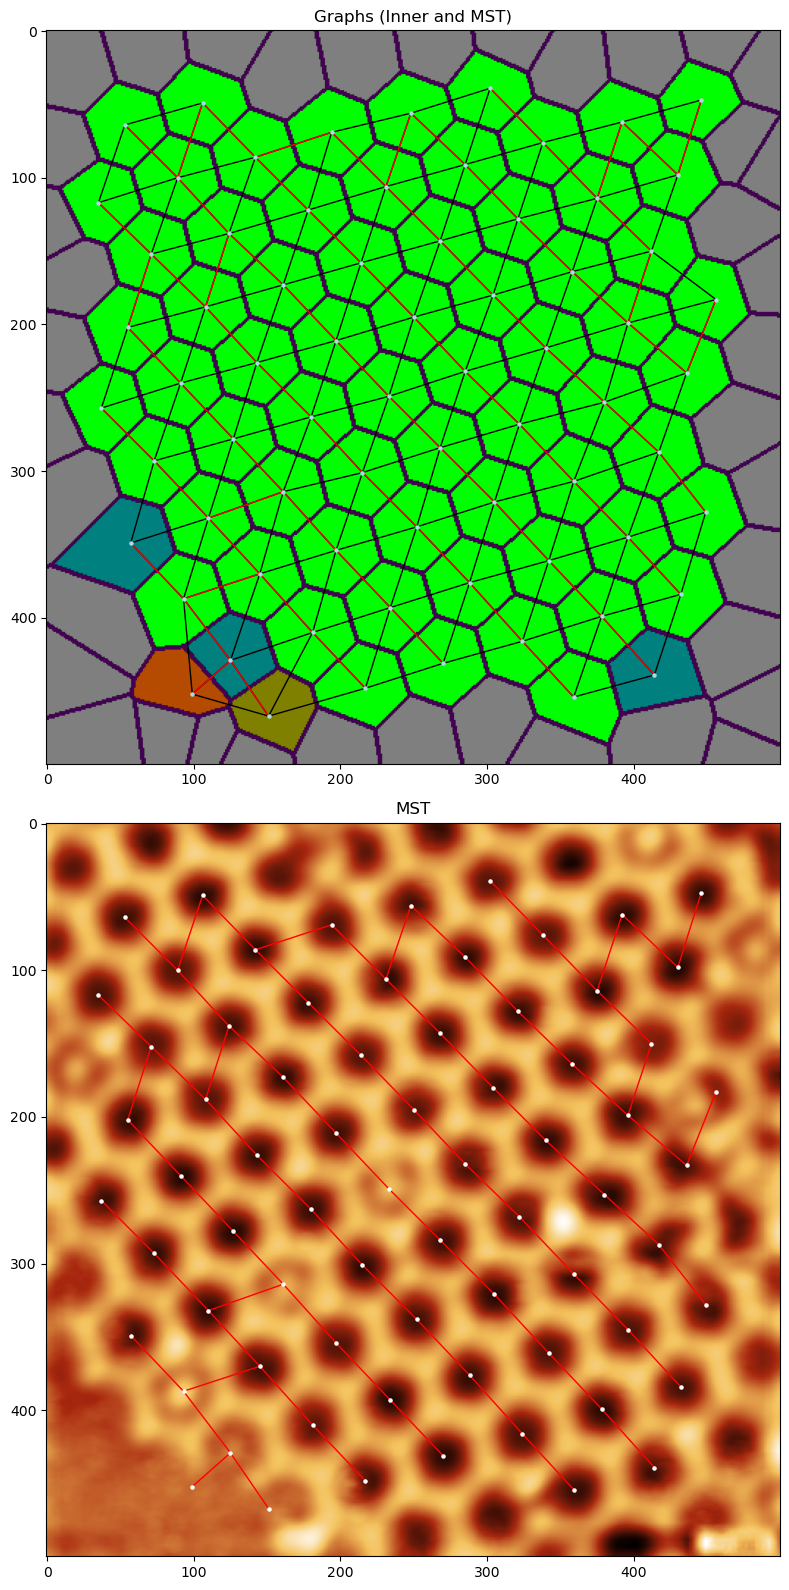

In [46]:
# get the pixel positions of the inner ggraph_inner
# and the minimum spanning tree
pos = {n:d['pixel_pos'] for n, d in graph_inner.nodes(data=True)}
pos_inner = {
            node:[dat['pixel_pos'][1],dat['pixel_pos'][0]] 
            for node, dat in graph_inner.nodes(data=True)
            }
pos_msf = {
            node:[dat['pixel_pos'][1],dat['pixel_pos'][0]] 
            for node, dat in g_msf.nodes(data=True)
            }


fig, ax = plt.subplots(2,1,figsize=(8,16))

ax[0].imshow(img_vor_deg_t)
ax[0].imshow(v_border)
ax[0].set_title('Graphs (Inner and MST)')

xlim = ax[0].get_xlim()
ylim = ax[0].get_ylim()
# draw the original inner graph

nx.draw_networkx_nodes(graph_inner, pos_inner, node_color="lightblue", node_size=5, 
                       ax=ax[0], hide_ticks=False)
nx.draw_networkx_edges(graph_inner, pos_inner, edge_color="black",
                       ax=ax[0], hide_ticks=False)

# draw the mst graph
nx.draw_networkx_edges(g_msf, pos_msf, edge_color="red",
                       ax=ax[0], hide_ticks=False)
ax[0].set_xlim(xlim)
ax[0].set_ylim(ylim)

ax[1].imshow(img.img)
ax[1].set_title('MST')
nx.draw_networkx_nodes(graph_inner, pos_inner, node_color="white", node_size=5, 
                       ax=ax[1], hide_ticks=False)
nx.draw_networkx_edges(g_msf, pos_msf, edge_color="red",
                       ax=ax[1], hide_ticks=False)
ax[1].set_xlim(xlim)
ax[1].set_ylim(ylim)

fig.tight_layout()

# THIS IS THE INFORMATION WE GET FROM THE FILENAME
print("--- {IMAGE INOFRMATION} ---")
print(f"IMAGE SIZE:    {img.nm_size} nm")
print(f"PIXELS (X):    {img.px_sizex} px")
print(f"PIXELS (Y):    {img.px_sizey} px")
print(f"IMAGE AREA:    {img.area} nm^2")
print(f"IMAGE SCALE:   {img.scale} px/nm")
print(f"# OF NODES:    {Nlabel}") 
print(f"FILE NAME:     {img.name}")

In [47]:
img_vor_t, img_vor_deg_t, v_border, graph_node, graph_inner, power = voronoi_tree(img, graph_node, k = k, power = power)
g_msf = nx.minimum_spanning_tree(graph_inner)
_, _, m, sig, _, defect_ratio = statistics(graph_node, graph_inner, g_msf) 

m_values, sig_values, defect_ratio_values, all_deg_lists = [], [], [], []

test_power = False
if test_power == True:
    print("      --- {STATISTICS} ---")
    print(f"MEAN EDGE LENGTH:     {m:.7f} nm")
    print(f"STANDARD DEVEATION:   {sig:.7f} nm")
    print(f"DEFECT RATIO:         {defect_ratio:.7f}")
    print(f"CURRENT POWER:        {power}")
    print("===============================================")

    power_list = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
    for power in power_list:
        img_vor_t, img_vor_deg_t, v_border, graph_node, graph_inner, power = voronoi_tree(img, graph_node, k = k, power = power)
        g_msf = nx.minimum_spanning_tree(graph_inner)
        _, _, m, sig, _, defect_ratio = statistics(graph_node, graph_inner, g_msf) 
        m_values.append(m)
        sig_values.append(sig)
        defect_ratio_values.append(defect_ratio)
        print(f"POWER={power:.1f} m={m:.7f}, std={sig:.7f}, defect ratio={defect_ratio:.7f}")
        #print("")
        power = power + 0.1
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(power_list, m_values, 'o-', linewidth=2, markersize=8)
    axes[0].set_xlabel('Power', fontsize=12)
    axes[0].set_ylabel('Mean Edge Length (nm)', fontsize=12)
    axes[0].set_title('Mean Edge Length vs Power', fontsize=12)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(power_list, sig_values, 's-', linewidth=2, markersize=8, color='orange')
    axes[1].set_xlabel('Power', fontsize=12)
    axes[1].set_ylabel('Standard Deviation (nm)', fontsize=12)
    axes[1].set_title('Std Dev vs Power', fontsize=12)
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(power_list, defect_ratio_values, '^-', linewidth=2, markersize=8, color='red')
    axes[2].set_xlabel('Power', fontsize=12)
    axes[2].set_ylabel('Defect Ratio', fontsize=12)
    axes[2].set_title('Defect Ratio vs Power', fontsize=12)
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# THE PLOTS ARE STABLE IN THE RANGE (0.0, 8.0) SO WE CHOOSE POWER IN THE MIDDLE, OR SLIGHTLY CLOSER TO 0.0. WE CHOOSE POWER = 0.3

In [48]:
G_base = find_nodes(label_mask, Nlabel, 10, img.scale)
test_k = True
if test_k == True:
    print("      --- {STATISTICS} ---")
    print(f"MEAN EDGE LENGTH:     {m:.7f} nm")
    print(f"STANDARD DEVEATION:   {sig:.7f} nm")
    print(f"DEFECT RATIO:         {defect_ratio:.7f}")
    print(f"CURRENT POWER:        {power}")
    print("===============================================")

    k_list = [4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24]
    for k in k_list:
        img_vor, img_vor_deg, img_vor_boarder, G, G_inner, G_filtered = voronoi_tree(img, G_base.copy(), k=k)
        G_MSF = nx.minimum_spanning_tree(G_inner)
        deg_list, deg, m, std, S, defect_ratio = statistics(G, G_inner, G_MSF)
        m_values.append(m)
        sig_values.append(std)
        defect_ratio_values.append(defect_ratio)
        all_deg_lists.append(deg_list) # Append deg_list to the new list
        print(f"k={k}: m={m:.3f}, std={std:.3f}, defect ratio={defect_ratio:.3f}")
        k = k + 2

      --- {STATISTICS} ---
MEAN EDGE LENGTH:     0.2237197 nm
STANDARD DEVEATION:   0.0103167 nm
DEFECT RATIO:         0.0704225
CURRENT POWER:        0.3
k=4: m=0.224, std=0.010, defect ratio=0.070
k=6: m=0.224, std=0.010, defect ratio=0.070
k=8: m=0.224, std=0.010, defect ratio=0.070
k=10: m=0.224, std=0.010, defect ratio=0.070
k=12: m=0.224, std=0.010, defect ratio=0.070
k=14: m=0.224, std=0.010, defect ratio=0.070
k=16: m=0.224, std=0.010, defect ratio=0.070
k=18: m=0.224, std=0.010, defect ratio=0.070
k=20: m=0.224, std=0.010, defect ratio=0.070
k=22: m=0.224, std=0.010, defect ratio=0.070
k=24: m=0.224, std=0.010, defect ratio=0.070
